### Import Modules

In [1]:
# Standard Library
import random, traceback
from IPython.display import display
from os import environ
from pathlib import Path

# Packages
import mlflow, optuna, torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from dotenv import load_dotenv
from mlflow import MlflowClient, pyfunc
from mlflow.models import infer_signature
from numpy import ndarray
from optuna.samplers import TPESampler
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, average_precision_score, recall_score,
    precision_score, roc_auc_score, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sqlalchemy import create_engine
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from xgboost import XGBClassifier

### Constants & Config

In [2]:
# Environment
load_dotenv()

# Paths
ROOT_DIR = Path("../").resolve()

# SQL
ENGINE = create_engine(
    f"postgresql://{environ['POSTGRES_USER']}:{environ['POSTGRES_PASSWORD']}"
    f"@{environ['POSTGRES_HOST']}:{environ['POSTGRES_PORT']}/{environ['FRAUD_DETECTION_DB']}"
)

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Cross Validation
TEST_SIZE = 0.2
CV_VAL_SIZE = TEST_SIZE / (1 - TEST_SIZE)  # 60/20/20 train/val/test — val is 20% of whole dataset (= 25% of train, 0.2/0.8)
CV = StratifiedKFold(n_splits=int(1 / CV_VAL_SIZE), shuffle=True, random_state=RANDOM_STATE)

# Hyperparameter Optimization
BAYES_STEPS = 30
ACTIVATION_MAP = {"relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU}

# Torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE.type}")
mp.set_start_method("spawn", force=True)

# Optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# MLflow
mlflow.set_tracking_uri(f"http://{environ['MLFLOW_HOST']}:{environ['MLFLOW_PORT']}")
EXPERIMENT_NAME = "fraud_detection"
if not mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    mlflow.create_experiment(name=EXPERIMENT_NAME)
mlflow.set_experiment(EXPERIMENT_NAME)

# # Classes
# class WindowedDataset(Dataset):
#     """Sliding-window dataset: X[i] = rows [i : i+window], y[i] = label at position i+window (the label immediately following the window — one-step-ahead target)."""
#     def __init__(self, x: ndarray, y: ndarray, window: int):
#         self.x      = torch.tensor(x, dtype=torch.float32)
#         self.y      = torch.tensor(y, dtype=torch.float32)
#         self.window = window
#
#     def __len__(self) -> int:
#         return len(self.x) - self.window
#
#     def __getitem__(self, i):
#         return self.x[i : i + self.window], self.y[i + self.window]


Device: cpu


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1779195215722, experiment_id='1', last_update_time=1779195215722, lifecycle_stage='active', name='fraud_detection', tags={}, trace_location=None, workspace='default'>

### Helpers

In [3]:
def get_predictions_pyfunc(
    model: pyfunc.PythonModel,
    x: ndarray,
    threshold: float = 0.5
) -> dict[str, ndarray]:
    return {
        "y_pred": model.predict(None, x, params={"threshold": threshold}),
        "y_prob": model.predict(None, x, params={"probabilities": True})[:, 1]
    }

def get_predictions_sklearn(
    model: BaseEstimator,
    x: ndarray,
    threshold: float = 0.5
) -> dict[str, ndarray]:
    y_prob = model.predict_proba(x)[:, 1]
    return {
        "y_pred": (y_prob >= threshold).astype(int),
        "y_prob": y_prob
    }

def evaluate_model_predictions(
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray
) -> dict:
    return {
        "F1 score": f1_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

def visualize_model_predictions(
    title: str,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    y_true: np.ndarray,
    threshold: float = 0.5,
) -> dict:
    confusion_matrix_figure, confusion_matrix_ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Legitimate", "Fraud"],
        normalize="true",
        cmap='Blues',
        values_format='.1%',
        ax=confusion_matrix_ax
    )
    confusion_matrix_ax.set_title(title)

    probability_scatter_figure, probability_scatter_ax = plt.subplots()
    probability_scatter_ax.scatter(
        y_prob,
        range(len(y_true)),
        c=np.where(y_true == 1, "red", "blue"),
        edgecolors="k"
    )
    probability_scatter_ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    probability_scatter_ax.axvline(x=threshold, alpha=0.3, color="white", linestyle="--")
    probability_scatter_ax.axvspan(threshold, 1.0, alpha=0.05, color='red')
    probability_scatter_ax.axvspan(0.0, threshold, alpha=0.05, color='blue')
    probability_scatter_ax.set_yticks([])
    probability_scatter_ax.set_ylabel("Transactions")
    probability_scatter_ax.set_xlabel("Fraud Probability Score")
    probability_scatter_ax.set_title(title)

    return {
        f"probability_scatter_{title.lower()}": probability_scatter_figure,
        f"confusion_matrix_{title.lower()}": confusion_matrix_figure,
    }

### Load Data

In [4]:
data_names = ("train_x", "train_y", "test_x", "test_y")
with ENGINE.connect() as connection:
    train_x, train_y, test_x, test_y = [
        pd.read_sql(f"SELECT * FROM preprocessed_transactions_{name}", connection)
        for name in data_names
    ]

for name, df in dict(zip(data_names, [train_x, train_y, test_x, test_y])).items():
    print(f"Loaded {len(df):,} rows from {name}")
print(f"\ntrain_x : {train_x.shape}  train_y : {train_y.shape}")
print(f"test_x  : {test_x.shape}   test_y  : {test_y.shape}")

train_x_np = train_x.values.astype(np.float32)
train_y_np = train_y.values.ravel().astype(np.int64)
test_x_np  = test_x.values.astype(np.float32)
test_y_np  = test_y.values.ravel().astype(np.int64)

train_y_np_positive_weight = (train_y_np == 0).sum() / (train_y_np == 1).sum()
print(f"\npositive_weight: {train_y_np_positive_weight}")

train_x_np_dimensions_size = train_x_np.shape[1]

Loaded 454,902 rows from train_x
Loaded 454,902 rows from train_y
Loaded 56,962 rows from test_x
Loaded 56,962 rows from test_y

train_x : (454902, 30)  train_y : (454902, 1)
test_x  : (56962, 30)   test_y  : (56962, 1)

positive_weight: 1.0


KNN
  Best Hyperparameters: {'n_neighbors': 19, 'weights': 'distance', 'p': 1, 'leaf_size': 87}


,Metric,Score
0,F1 score,0.411311
1,PR-AUC,0.646992
2,Recall,0.816327
3,Precision,0.274914
4,ROC-AUC,0.922387
5,Accuracy,0.995980


2026/05/20 06:19:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Successfully registered model 'KNN'.
2026/05/20 06:19:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: KNN, version 1
Created version '1' of model 'KNN'.


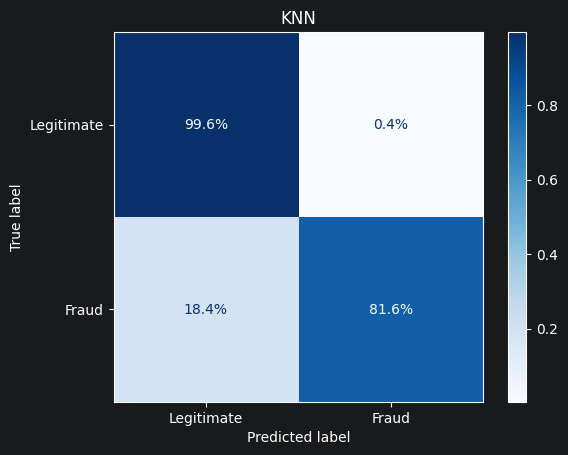

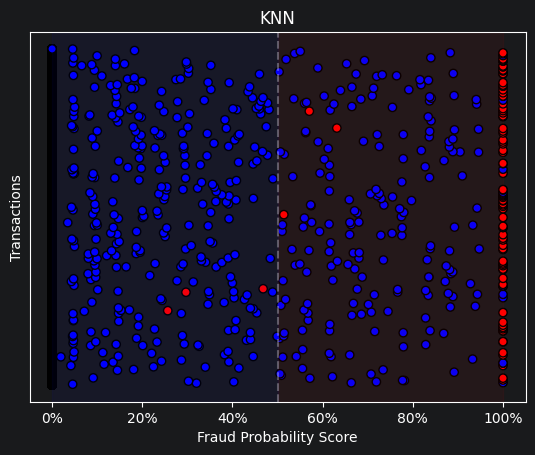

🏃 View run KNN at: http://localhost:5000/#/experiments/1/runs/4ff64d1f17134bf298b2d066f5e234ee
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [29]:
with mlflow.start_run(run_name="KNN") as run:
    try:
        model_name = "knn"
        run_name_str = str(run.info.run_name)

        def knn_objective(trial: optuna.Trial) -> float:
            knn_params = {
                f"n_neighbors": trial.suggest_int(f"n_neighbors", 1, 30),
                f"weights":     trial.suggest_categorical(f"weights", ["uniform", "distance"]),
                f"p":           trial.suggest_int(f"p", 1, 2),
                f"leaf_size":   trial.suggest_int(f"leaf_size", 60, 120),
            }

            return float(np.mean(cross_val_score(
                Pipeline([
                    ("robust_scaler", RobustScaler()),
                    (model_name, KNeighborsClassifier(**knn_params, n_jobs=-1)),
                ]),
                train_x_np,
                train_y_np,
                cv=CV,
                scoring="average_precision",
                n_jobs=1
            )))

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_STATE, multivariate=True)
        )
        study.optimize(
            knn_objective,
            n_trials=BAYES_STEPS,
            n_jobs=1,
            show_progress_bar=True,
            gc_after_trial=True,
            timeout=3600
        )

        knn_best_params = study.best_params
        knn_best_model = Pipeline([
            ("robust_scaler", RobustScaler()),
            (model_name,
                Pipeline([
                    ("robust_scaler", RobustScaler()),
                    (model_name, KNeighborsClassifier(**knn_best_params, n_jobs=-1)),
                ])
            ),
        ]).fit(train_x_np, train_y_np)

        knn_predictions = get_predictions_sklearn(knn_best_model, test_x_np)
        knn_metrics = evaluate_model_predictions(**knn_predictions, y_true=test_y_np)
        knn_figures = visualize_model_predictions(**knn_predictions, y_true=test_y_np, title=run_name_str)

        print(run_name_str)
        print(f"  Best Hyperparameters: {knn_best_params}")
        display(pd.DataFrame(knn_metrics.items(), columns=["Metric", "Score"]))

        knn_model_info = mlflow.sklearn.log_model(
            sk_model=knn_best_model,
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=knn_best_model.predict(test_x_np)
            ),
            input_example=test_x_np[:5],
            pip_requirements=["scikit-learn==1.8.0", "numpy==2.4.6", "pandas==2.3.3"],
            name="model",
        )
        mlflow.log_params(params=knn_best_params, run_id=knn_model_info.run_id)
        mlflow.log_metrics(
            metrics=knn_metrics,
            run_id=knn_model_info.run_id,
            model_id=knn_model_info.model_id
        )
        for name, figure in knn_figures.items():
            plt.show()
            mlflow.log_figure(figure, f"{name}.png")
            plt.close(figure)
    except:
        run_id_str = str(run.info.run_id)
        client = MlflowClient()
        mlflow.delete_run(run_id_str)
        try:
            versions = client.search_model_versions(f"run_id='{run_id_str}'")
            for v in versions: client.delete_model_version(name=v.name, version=v.version)
        except: pass
        traceback.print_exc()

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done 204 out of 204 | elapsed:    0.8s finished


Random_Forest
  Best Hyperparameters: {'n_estimators': 204, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.6935937269634344}


,Metric,Score
0,F1 score,0.790000
1,PR-AUC,0.803207
2,Recall,0.806122
3,Precision,0.774510
4,ROC-AUC,0.976233
5,Accuracy,0.999263


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 204 out of 204 | elapsed:    0.1s finished
2026/05/20 06:23:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 204 out of 204 | elapsed:    0.0s finished
Registered model 'Random_Forest' already exists. Creating a new version of this model...
2026/05/20 06:23:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Random_Forest, version 2
Created version '2' of model 'Random_Forest'.


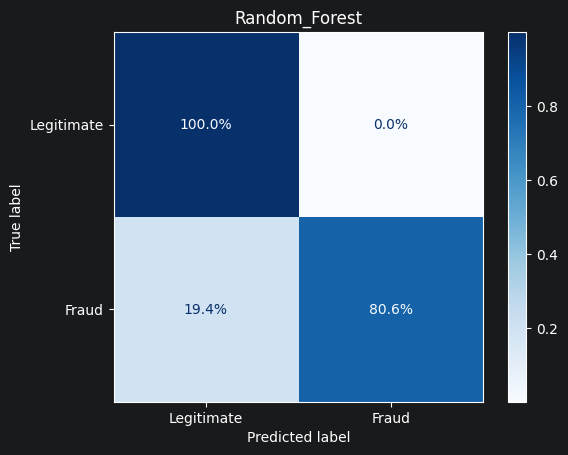

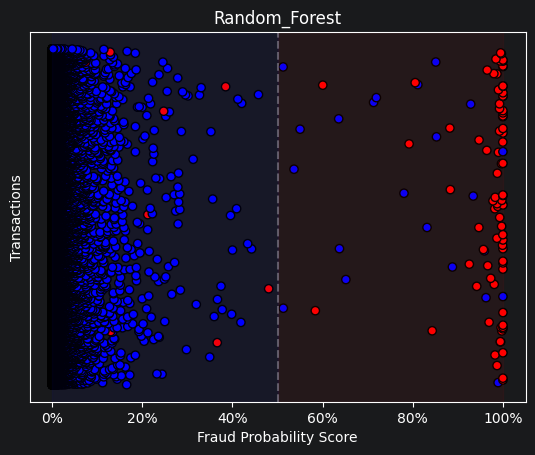

🏃 View run Random_Forest at: http://localhost:5000/#/experiments/1/runs/cdf786e019f747d580c5ce5114b6a8ba
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [33]:
with mlflow.start_run(run_name="Random_Forest") as run:
    try:
        model_name = "rf"
        run_name_str = str(run.info.run_name)

        def rf_objective(trial: optuna.Trial) -> float:
            rf_params = {
                "n_estimators":      trial.suggest_int("n_estimators", 100, 300),
                "max_depth":         trial.suggest_int("max_depth", 5, 15),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
                "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
                "max_samples":       trial.suggest_float("max_samples", 0.5, 1.0),
            }

            return float(np.mean(cross_val_score(
                Pipeline([
                    ("robust_scaler", RobustScaler()),
                    (model_name,
                        RandomForestClassifier(
                            **rf_params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=1
                        )
                    ),
                ]),
                train_x_np,
                train_y_np,
                cv=CV,
                scoring="average_precision",
                n_jobs=1
            )))

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_STATE, multivariate=True)
        )
        study.optimize(
            rf_objective,
            n_trials=BAYES_STEPS,
            n_jobs=1,
            show_progress_bar=True,
            gc_after_trial=True,
            timeout=3600
        )

        rf_best_params = study.best_params
        rf_best_model = Pipeline([
            ("robust_scaler", RobustScaler()),
            (model_name,
                RandomForestClassifier(
                    **rf_best_params, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=2
                )
            ),
        ]).fit(train_x_np, train_y_np)

        rf_predictions = get_predictions_sklearn(rf_best_model, test_x_np)
        rf_metrics = evaluate_model_predictions(**rf_predictions, y_true=test_y_np)
        rf_figures = visualize_model_predictions(**rf_predictions, y_true=test_y_np, title=run_name_str)

        print(run_name_str)
        print(f"  Best Hyperparameters: {rf_best_params}")
        display(pd.DataFrame(rf_metrics.items(), columns=["Metric", "Score"]))

        rf_model_info = mlflow.sklearn.log_model(
            sk_model=rf_best_model,
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=rf_best_model.predict(test_x_np)
            ),
            input_example=test_x_np[:5],
            pip_requirements=["scikit-learn==1.8.0", "numpy==2.4.6", "pandas==2.3.3"],
            name="model",
        )
        mlflow.log_params(params=rf_best_params, run_id=rf_model_info.run_id)
        mlflow.log_metrics(
            metrics=rf_metrics,
            run_id=rf_model_info.run_id,
            model_id=rf_model_info.model_id
        )
        for name, figure in rf_figures.items():
            plt.show()
            mlflow.log_figure(figure, f"{name}.png")
            plt.close(figure)
    except:
        run_id_str = str(run.info.run_id)
        client = MlflowClient()
        mlflow.delete_run(run_id_str)
        try:
            versions = client.search_model_versions(f"run_id='{run_id_str}'")
            for v in versions: client.delete_model_version(name=v.name, version=v.version)
        except: pass
        traceback.print_exc()

XGBoost
  Best Hyperparameters: {'n_estimators': 372, 'max_depth': 4, 'learning_rate': 0.25510811916319726, 'subsample': 0.7962847867227502, 'colsample_bytree': 0.939274056922528, 'reg_alpha': 1.663358377704278e-05, 'reg_lambda': 8.110477000683634e-06, 'gamma': 0.15223077652785688, 'min_child_weight': 10}


,Metric,Score
0,F1 score,0.818653
1,PR-AUC,0.821497
2,Recall,0.806122
3,Precision,0.831579
4,ROC-AUC,0.983557
5,Accuracy,0.999386


2026/05/20 06:19:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Successfully registered model 'XGBoost'.
2026/05/20 06:19:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost, version 1
Created version '1' of model 'XGBoost'.


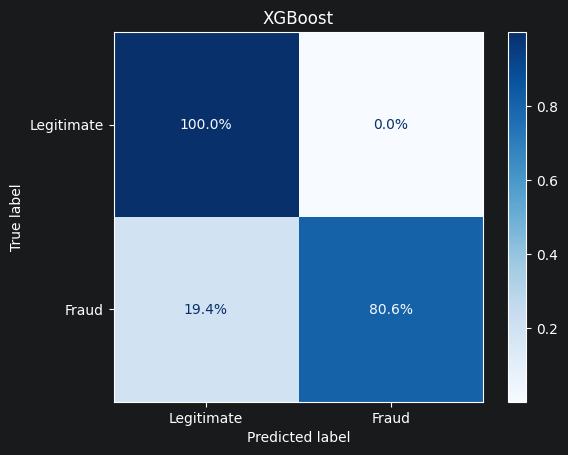

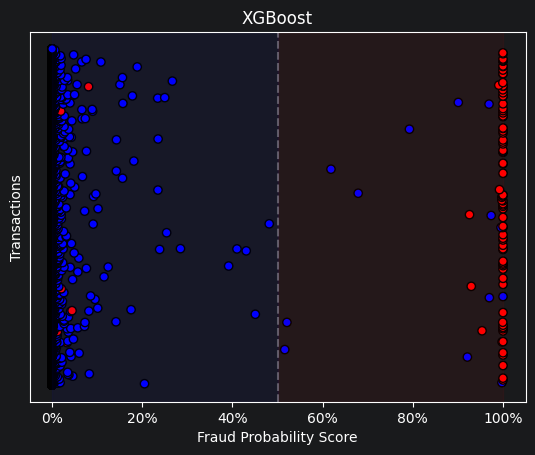

🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/1fcd305d44e149b5bd5ef9c0759c854f
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [31]:
with mlflow.start_run(run_name="XGBoost") as run:
    try:
        model_name = "xgb"
        run_name_str = str(run.info.run_name)

        def xgb_objective(trial: optuna.Trial) -> float:
            xgb_params = {
                f"n_estimators":      trial.suggest_int(f"n_estimators", 100, 500),
                f"max_depth":         trial.suggest_int(f"max_depth", 3, 10),
                f"learning_rate":     trial.suggest_float(f"learning_rate", 0.005, 0.3, log=True),
                f"subsample":         trial.suggest_float(f"subsample", 0.5, 1.0),
                f"colsample_bytree":  trial.suggest_float(f"colsample_bytree", 0.4, 1.0),
                f"reg_alpha":         trial.suggest_float(f"reg_alpha", 1e-6, 1.0, log=True),
                f"reg_lambda":        trial.suggest_float(f"reg_lambda", 1e-6, 5.0, log=True),
                f"gamma":             trial.suggest_float(f"gamma", 0.0, 5.0),
                f"min_child_weight":  trial.suggest_int(f"min_child_weight", 1, 10),
            }

            return float(np.mean(cross_val_score(
                Pipeline([
                    ("robust_scaler", RobustScaler()),
                    (model_name,
                        XGBClassifier(
                            **xgb_params, scale_pos_weight=train_y_np_positive_weight, random_state=RANDOM_STATE, n_jobs=-1, verbosity=2
                        )
                    ),
                ]),
                train_x_np,
                train_y_np,
                cv=CV,
                scoring="average_precision",
                n_jobs=1
            )))

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_STATE, multivariate=True),
        )
        study.optimize(
            xgb_objective,
            n_trials=BAYES_STEPS,
            n_jobs=1,
            show_progress_bar=True,
            gc_after_trial=True,
            timeout=3600
        )

        xgb_best_params = study.best_params
        xgb_best_model = Pipeline([
            ("robust_scaler", RobustScaler()),
            (model_name,
                XGBClassifier(
                    **xgb_best_params, scale_pos_weight=train_y_np_positive_weight, random_state=RANDOM_STATE, n_jobs=-1, verbosity=2
                )
            ),
        ]).fit(train_x_np, train_y_np)

        xgb_predictions = get_predictions_sklearn(xgb_best_model, test_x_np)
        xgb_metrics = evaluate_model_predictions(**xgb_predictions, y_true=test_y_np)
        xgb_figures = visualize_model_predictions(**xgb_predictions, y_true=test_y_np, title=run_name_str)

        print(run_name_str)
        print(f"  Best Hyperparameters: {xgb_best_params}")
        display(pd.DataFrame(xgb_metrics.items(), columns=["Metric", "Score"]))

        xgb_model_info = mlflow.sklearn.log_model(
            sk_model=xgb_best_model,
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=xgb_best_model.predict(test_x_np)
            ),
            input_example=test_x_np[:5],
            pip_requirements=["xgboost==3.2.0", "scikit-learn==1.8.0", "numpy==2.4.6", "pandas==2.3.3"],
            name="model",
            skops_trusted_types=["xgboost.core.Booster", "xgboost.sklearn.XGBClassifier"],
        )
        mlflow.log_params(params=xgb_best_params, run_id=xgb_model_info.run_id)
        mlflow.log_metrics(
            metrics=xgb_metrics,
            run_id=xgb_model_info.run_id,
            model_id=xgb_model_info.model_id
        )
        for name, figure in xgb_figures.items():
            plt.show()
            mlflow.log_figure(figure, f"{name}.png")
            plt.close(figure)
    except:
        run_id_str = str(run.info.run_id)
        client = MlflowClient()
        mlflow.delete_run(run_id_str)
        try:
            versions = client.search_model_versions(f"run_id='{run_id_str}'")
            for v in versions: client.delete_model_version(name=v.name, version=v.version)
        except: pass
        traceback.print_exc()

2026/05/20 06:19:33 WARNING mlflow.types.type_hints: Union type hint is inferred as AnyType, and MLflow doesn't validate the data against its element types.


MLP
  Best Hyperparameters: {'hidden_size': 185, 'num_layers': 2, 'activation': 'relu', 'dropout': 0.10993652970313339, 'lr': 0.0014699953496756036, 'weight_decay': 0.006495058423828482, 'batch_size': 192, 'epochs': 9}


,Metric,Score
0,F1 score,0.781726
1,PR-AUC,0.806203
2,Recall,0.785714
3,Precision,0.777778
4,ROC-AUC,0.951777
5,Accuracy,0.999245


2026/05/20 06:19:34 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/05/20 06:19:34 INFO mlflow.pyfunc: Validating input example against model signature
2026/05/20 06:19:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Successfully registered model 'MLP'.
2026/05/20 06:19:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MLP, version 1
Created version '1' of model 'MLP'.


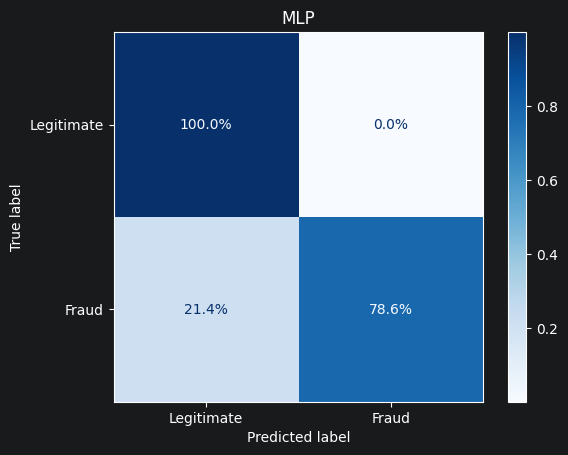

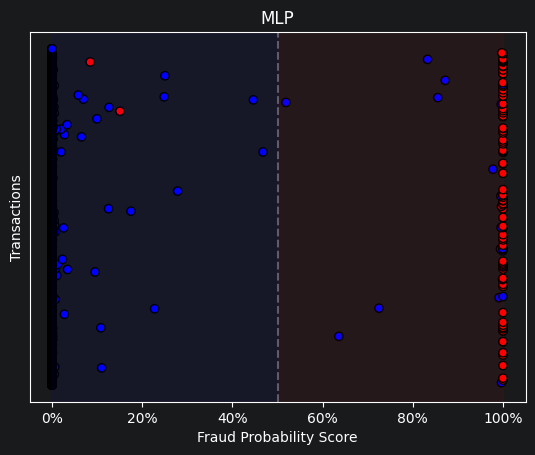

🏃 View run MLP at: http://localhost:5000/#/experiments/1/runs/10686022397d4c21a078db45bfb4840d
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [32]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        activation: str,
        dropout: float,
        epochs: int,
        batch_size: int,
        lr: float,
        weight_decay: float,
        pos_weight: float,
        device: torch.device,
    ):
        super().__init__()
        activation_function = ACTIVATION_MAP[activation]

        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        in_sz = input_size
        for _ in range(num_layers):
            self.linears.append(nn.Linear(in_sz, hidden_size))
            self.activations.append(activation_function())
            in_sz = hidden_size
        self.output = nn.Linear(in_sz, 1)

        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32))
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.device = device
        self.to(device)

    def forward(self, x: Tensor) -> Tensor:
        for linear, activation in zip(self.linears, self.activations):
            x = activation(linear(x))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.output(x).squeeze(1)

    def fit(self, x: ndarray, y: ndarray, pbar: tqdm | None = None) -> "MLP":
        loader = DataLoader(
            TensorDataset(
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32)
            ),
            batch_size=self.batch_size, shuffle=True,
            pin_memory=self.device.type == "cuda",
        )
        self.train()
        for epoch in range(self.epochs):
            epoch_loss = 0.0

            for x_batch, y_batch in loader:
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                self.optimizer.zero_grad()
                y_pred = self(x_batch)
                loss = self.criterion(y_pred, y_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()

            if pbar is not None:
                with pbar.get_lock():
                    pbar.reset(total=self.epochs)
                    pbar.n = epoch + 1
                    pbar.set_postfix(loss=f"{epoch_loss / (len(loader)):.4f}")

        return self

    def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
        self.eval()
        device = next(self.parameters()).device
        with torch.no_grad():
            tensor = torch.tensor(x, dtype=torch.float32).to(device)
            logits = self(tensor)
            return (torch.sigmoid(logits).cpu().numpy() >= threshold).astype(int)

    def predict_proba(self, x: ndarray) -> ndarray:
        self.eval()
        device = next(self.parameters()).device
        with torch.no_grad():
            tensor = torch.tensor(x, dtype=torch.float32).to(device)
            prob = torch.sigmoid(self(tensor)).cpu().numpy()
            return np.stack([1 - prob, prob], axis=1)

class MLPPipeline(pyfunc.PythonModel):
    def __init__(self, mlp, robust_scaler):
        self.mlp = mlp
        self.robust_scaler = robust_scaler

    def predict(
        self,
        context: mlflow.pyfunc.PythonModelContext,
        model_input: list[pd.DataFrame | np.ndarray],
        params: dict | None = None
    ) -> np.ndarray:
        params = params or {}

        if isinstance(model_input, pd.DataFrame):
            model_input = model_input.values
        model_input = self.robust_scaler.transform(model_input)

        if params.get("probabilities", False):
            return self.mlp.predict_proba(model_input)

        return self.mlp.predict(model_input, threshold=params.get("threshold", 0.5))

with mlflow.start_run(run_name="MLP") as run:
    try:
        run_name_str = str(run.info.run_name)

        with tqdm(desc="MLP", dynamic_ncols=True) as pbar:
            def mlp_objective(trial: optuna.Trial) -> float:
                mlp_params = {
                    "hidden_size":  trial.suggest_int("hidden_size", 32, 256),
                    "num_layers":   trial.suggest_int("num_layers", 2, 4),
                    "activation":   trial.suggest_categorical("activation", ["relu", "gelu", "silu"]),
                    "dropout":      trial.suggest_float("dropout", 0.0, 0.5),
                    "lr":           trial.suggest_float("lr", 1e-5, 0.1, log=True),
                    "weight_decay": trial.suggest_float("weight_decay", 1e-8, 0.1, log=True),
                    "batch_size":   trial.suggest_int("batch_size", 64, 512, step=64),
                    "epochs":       trial.suggest_int("epochs", 3, 10),
                }

                ap_scores = []
                for tr_idx, val_idx in CV.split(train_x_np, train_y_np):
                    x_tr, x_val  = train_x_np[tr_idx], train_x_np[val_idx]
                    y_tr, y_val  = train_y_np[tr_idx], train_y_np[val_idx]

                    robust_scaler = RobustScaler()
                    train_x_scaled = robust_scaler.fit_transform(x_tr)
                    val_x_scaled = robust_scaler.transform(x_val)

                    pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
                    model = MLP(
                        **mlp_params,
                        input_size=train_x_scaled.shape[1],
                        pos_weight=pos_w,
                        device=DEVICE,
                    ).fit(train_x_scaled, y_tr, pbar)
                    ap_scores.append(
                        average_precision_score(
                            y_val,
                            model.predict_proba(val_x_scaled)[:, 1]
                        )
                    )

                return float(np.mean(ap_scores))

            study = optuna.create_study(
                direction="maximize",
                sampler=TPESampler(seed=RANDOM_STATE),
            )
            study.optimize(
                mlp_objective,
                n_trials=BAYES_STEPS,
                n_jobs=1,
                show_progress_bar=True,
                gc_after_trial=True,
                timeout=3600
            )

            mlp_robust_scaler = RobustScaler()
            train_x_scaled_np = mlp_robust_scaler.fit_transform(train_x_np)

            mlp_best_params = study.best_params
            mlp_best_model = MLPPipeline(
                mlp=MLP(
                    **mlp_best_params,
                    input_size=train_x_np_dimensions_size,
                    pos_weight=train_y_np_positive_weight,
                    device=DEVICE,
                ).fit(train_x_scaled_np, train_y_np, pbar),
                robust_scaler=mlp_robust_scaler
            )

            mlp_predictions = get_predictions_pyfunc(mlp_best_model, test_x_np)
            mlp_metrics = evaluate_model_predictions(**mlp_predictions, y_true=test_y_np)
            mlp_figures = visualize_model_predictions(**mlp_predictions, y_true=test_y_np, title=run_name_str)

            print(run_name_str)
            print(f"  Best Hyperparameters: {mlp_best_params}")
            display(pd.DataFrame(mlp_metrics.items(), columns=["Metric", "Score"]))

            mlp_model_info = mlflow.pyfunc.log_model(
                python_model=mlp_best_model,
                registered_model_name=run_name_str,
                signature=infer_signature(
                    model_input=test_x_np,
                    model_output=mlp_best_model.predict(None, test_x_np),
                    params={"probabilities": False, "threshold": 0.5}
                ),
                input_example=test_x_np[:5],
                pip_requirements=["torch==2.12.0", "scikit-learn==1.8.0", "numpy==2.4.6", "pandas==2.3.3"],
                name="model",
            )
            mlflow.log_params(params=mlp_best_params, run_id=mlp_model_info.run_id)
            mlflow.log_metrics(
                metrics=mlp_metrics,
                run_id=mlp_model_info.run_id,
                model_id=mlp_model_info.model_id
            )
            for name, figure in mlp_figures.items():
                plt.show()
                mlflow.log_figure(figure, f"{name}.png")
                plt.close(figure)
    except:
        run_id_str = str(run.info.run_id)
        client = MlflowClient()
        mlflow.delete_run(run_id_str)
        try:
            versions = client.search_model_versions(f"run_id='{run_id_str}'")
            for v in versions: client.delete_model_version(name=v.name, version=v.version)
        except: pass
        traceback.print_exc()

In [25]:
# loaded = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
#
# loaded.predict(test_x_np)              # scaler + knn applied automatically
#
# loaded.named_steps["robust_scaler"]    # the scaler
# loaded.named_steps["knn"]              # the knn model

# loaded = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
#
# loaded.predict(test_x_np)             # scaler + model applied automatically
#
# pipeline = loaded.unwrap_python_model()
# pipeline.robust_scaler                 # the RobustScaler
# pipeline.model                         # the MLP

In [ ]:
# # with mlflow.start_run(run_name="MLP") as run:
# try:
#     logr = TunedThresholdClassifierCV(
#         LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
#         scoring="f1",
#         random_state=RANDOM_STATE,
#         n_jobs=-1
#     ).fit(train_x_np, train_y_np)
#     logr_metrics = evaluate_sklearn(logr, test_x_np, test_y_np, threshold=logr.best_threshold_)
#     # mlflow.log_metrics(logr_metrics)
#     # mlflow.sklearn.log_model(logr)
#
#     # print(f"{run.info.run_name}")
#     display(pd.DataFrame(logr_metrics.items(), columns=["Metric", "Score"]))
# except:
#     # mlflow.delete_run(str(run.info.run_id))
#     traceback.print_exc()

In [ ]:
# print("=" * 60)
# print(" 2.  SVM - RBF Kernel")
# print("=" * 60)
#
# svm = SVC(kernel="rbf", probability=True, class_weight="balanced",
#           random_state=RANDOM_STATE, verbose=True)
# svm.fit(train_x_np, train_y_np)
#
# svm_metrics = test_sklearn(svm, test_x_np, test_y_np)
# save_sklearn("svm_rbf", svm, svm_metrics)
#
# print(svm_metrics["classification_report"])


In [ ]:
# print("=" * 60)
# print(" 6.  GRU")
# print("=" * 60)
#
# WINDOW_SIZE = 10
#
# print(f"[1/4] Building dataset (window={WINDOW_SIZE}, samples={len(train_x_sorted_nd) - WINDOW_SIZE:,})...")
# dataset = WindowedDataset(train_x_sorted_nd, train_y_sorted_nd, WINDOW_SIZE)
# train_torch_loader  = DataLoader(dataset, batch_size=512, shuffle=False,
#                      pin_memory=(DEVICE.type == "cuda"), num_workers=0)
# print(f"      ✔ {len(dataset):,} windows  |  {len(train_torch_loader):,} batches")
#
# # ── Model ─────────────────────────────────────────────────────────────────────
# class GRUBinaryClassifier(nn.Module):
#     def __init__(self, input_size: int, hidden_size: int = 64):
#         super().__init__()
#         self.gru  = nn.GRU(input_size, hidden_size, batch_first=True)
#         self.head = nn.Linear(hidden_size, 1)
#
#     def forward(self, x: Tensor) -> Tensor:
#         _, h_n = self.gru(x)
#         return self.head(h_n.squeeze(0)).squeeze(1)  # raw_data logits
#
#     def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
#         self.eval()
#         device = next(self.parameters()).device
#         with torch.no_grad():
#             logits = self(torch.tensor(x, dtype=torch.float32).to(device))
#             return (torch.sigmoid(logits).cpu().numpy() >= threshold).astype(int)
#
#     def predict_proba(self, x: ndarray) -> ndarray:
#         self.eval()
#         device = next(self.parameters()).device
#         with torch.no_grad():
#             probs = torch.sigmoid(self(torch.tensor(x, dtype=torch.float32).to(device))).cpu().numpy()
#             return np.stack([1 - probs, probs], axis=1)  # shape (n, 2)
#
#
# input_size = train_x_sorted_nd.shape[1]
# print(f"[2/4] Building model (input={input_size})...")
# gru      = GRUBinaryClassifier(input_size).to(DEVICE)
# n_params = sum(p.numel() for p in gru.parameters() if p.requires_grad)
# print(f"      ✔ {n_params:,} trainable parameters")
#
# # ── Training ──────────────────────────────────────────────────────────────────
# N_EPOCHS = 20
#
# pos_weight_gru = torch.tensor(
#     [(train_y_sorted_nd == 0).sum() / max((train_y_sorted_nd == 1).sum(), 1)],
#     dtype=torch.float32, device=DEVICE
# )
# criterion_gru = nn.BCEWithLogitsLoss(pos_weight=pos_weight_gru)
#
# optimizer = optim.AdamW(gru.parameters())
#
# print(f"[3/4] Training ({N_EPOCHS} epochs x {len(train_torch_loader):,} batches)...")
# gru.train()
# for epoch in range(1, N_EPOCHS + 1):
#     total_loss = total_tp = total_fp = total_fn = 0.0
#     bar = tqdm(train_torch_loader, desc=f"GRU {epoch}/{N_EPOCHS}", unit="batch", colour="green", dynamic_ncols=True)
#
#     for X_batch, y_batch in bar:
#         X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
#         optimizer.zero_grad()
#         preds = gru(X_batch)
#         loss  = criterion_gru(preds, y_batch)
#         loss.backward()
#         clip_grad_norm_(gru.parameters(), max_norm=1.0)
#         optimizer.step()
#
#         with torch.no_grad():
#             probs = torch.sigmoid(preds)
#             tp = (y_batch * probs).sum().item()
#             fp = ((1.0 - y_batch) * probs).sum().item()
#             fn = (y_batch * (1.0 - probs)).sum().item()
#             total_tp += tp; total_fp += fp; total_fn += fn
#
#         total_loss += loss.item()
#         bar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{(2*tp)/(2*tp+fp+fn+1e-8):.4f}")
#
#     avg_loss  = total_loss / len(train_torch_loader)
#     train_f1  = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + 1e-8)
#     precision = total_tp / (total_tp + total_fp + 1e-8)
#     recall    = total_tp / (total_tp + total_fn + 1e-8)
#     print(f"  epoch {epoch:>2}/{N_EPOCHS}  loss={avg_loss:.4f}  F1={train_f1:.4f}  prec={precision:.4f}  rec={recall:.4f}")
#
# # ── Evaluate + Save ───────────────────────────────────────────────────────────
# print("[4/4] Evaluating and saving...")
# test_ds   = WindowedDataset(test_x_sorted_nd, test_y_sorted_nd, WINDOW_SIZE)
# test_x_w  = np.stack([test_ds[i][0].numpy() for i in range(len(test_ds))])
# test_y_w  = np.array([test_ds[i][1].numpy() for i in range(len(test_ds))]).astype(int)
# gru_metrics = evaluate_torch(gru, test_x_w, test_y_w)
# save_torch_model("gru", gru, gru_metrics)
# print(gru_metrics["classification_report"])


In [ ]:
# print("=" * 60)
# print(" 7.  Transformer")
# print("=" * 60)
#
# WINDOW_SIZE = 10
#
# # ── Dataset (reuses WindowedDataset from setup cell) ─────────────────────────
# print(f"[1/4] Building dataset (window={WINDOW_SIZE}, samples={len(train_x_sorted_nd) - WINDOW_SIZE:,})...")
# dataset = WindowedDataset(train_x_sorted_nd, train_y_sorted_nd, WINDOW_SIZE)
# train_torch_loader  = DataLoader(dataset, batch_size=512, shuffle=False,
#                      pin_memory=(DEVICE.type == "cuda"), num_workers=0)
# print(f"      ✔ {len(dataset):,} windows  |  {len(train_torch_loader):,} batches")
#
# # ── Model ─────────────────────────────────────────────────────────────────────
# class TransactionTransformer(nn.Module):
#     def __init__(self, input_size: int, d_model: int = 64, nhead: int = 4, num_layers: int = 2):
#         super().__init__()
#         self.input_proj = nn.Linear(input_size, d_model)
#         self.pos_enc    = nn.Embedding(512, d_model)        # learnable positional encoding
#         encoder_layer   = nn.TransformerEncoderLayer(
#                               d_model, nhead, dim_feedforward=128,
#                               batch_first=True, dropout=0.1)
#         self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
#         self.head       = nn.Linear(d_model, 1)
#
#     def forward(self, x):                                   # x: (batch, window, features)
#         positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
#         h = self.input_proj(x) + self.pos_enc(positions)   # project + add position info
#         h = self.encoder(h)                                 # bidirectional attention over window
#         return self.head(h[:, -1, :]).squeeze(1)            # classify from last timestep
#
#     def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
#         self.eval()
#         device = next(self.parameters()).device
#         with torch.no_grad():
#             logits = self(torch.tensor(x, dtype=torch.float32).to(device))
#             return (torch.sigmoid(logits).cpu().numpy() >= threshold).astype(int)
#
#     def predict_proba(self, x: ndarray) -> ndarray:
#         self.eval()
#         device = next(self.parameters()).device
#         with torch.no_grad():
#             probs = torch.sigmoid(self(torch.tensor(x, dtype=torch.float32).to(device))).cpu().numpy()
#             return np.stack([1 - probs, probs], axis=1)  # shape (n, 2)
#
#
# input_size = train_x_sorted_nd.shape[1]
# print(f"[2/4] Loading Transformer + column projection ({input_size} features)...")
# transformer  = TransactionTransformer(input_size).to(DEVICE)
# n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
# print(f"      ✔ {n_params:,} trainable parameters")
#
# # ── Training ──────────────────────────────────────────────────────────────────
# N_EPOCHS = 20
#
# pos_weight_rob = torch.tensor(
#     [(train_y_sorted_nd == 0).sum() / max((train_y_sorted_nd == 1).sum(), 1)],
#     dtype=torch.float32, device=DEVICE
# )
# criterion_rob = nn.BCEWithLogitsLoss(pos_weight=pos_weight_rob)
#
# optimizer = optim.AdamW(filter(lambda p: p.requires_grad, transformer.parameters()), lr=1e-3)
#
# print(f"[3/4] Training ({N_EPOCHS} epochs x {len(train_torch_loader):,} batches)...")
# transformer.train()
# for epoch in range(1, N_EPOCHS + 1):
#     total_loss = total_tp = total_fp = total_fn = 0.0
#     bar = tqdm(train_torch_loader, desc=f"Transformer {epoch}/{N_EPOCHS}", unit="batch", colour="green", dynamic_ncols=True)
#
#     for X_batch, y_batch in bar:
#         X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
#         optimizer.zero_grad()
#         preds = transformer(X_batch)
#         loss  = criterion_rob(preds, y_batch)
#         loss.backward()
#         clip_grad_norm_(transformer.parameters(), max_norm=1.0)
#         optimizer.step()
#
#         with torch.no_grad():
#             probs = torch.sigmoid(preds)
#             tp = (y_batch * probs).sum().item()
#             fp = ((1.0 - y_batch) * probs).sum().item()
#             fn = (y_batch * (1.0 - probs)).sum().item()
#             total_tp += tp; total_fp += fp; total_fn += fn
#
#         total_loss += loss.item()
#         bar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{(2*tp)/(2*tp+fp+fn+1e-8):.4f}")
#
#     avg_loss  = total_loss / len(train_torch_loader)
#     train_f1  = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + 1e-8)
#     precision = total_tp / (total_tp + total_fp + 1e-8)
#     recall    = total_tp / (total_tp + total_fn + 1e-8)
#     print(f"  epoch {epoch:>2}/{N_EPOCHS}  loss={avg_loss:.4f}  F1={train_f1:.4f}  prec={precision:.4f}  rec={recall:.4f}")
#
# # ── Evaluate + Save ───────────────────────────────────────────────────────────
# print("[4/4] Evaluating and saving...")
# test_ds   = WindowedDataset(test_x_sorted_nd, test_y_sorted_nd, WINDOW_SIZE)
# test_x_w  = np.stack([test_ds[i][0].numpy() for i in range(len(test_ds))])
# test_y_w  = np.array([test_ds[i][1].numpy() for i in range(len(test_ds))]).astype(int)
# transformer_metrics = evaluate_torch(transformer, test_x_w, test_y_w)
# save_torch_model("transformer", transformer, transformer_metrics)
# print(transformer_metrics["classification_report"])
